In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/retail_sales_dataset.csv')
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB
None
   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21    

/tmp/ipykernel_9983/3266172541.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Product Category', y='Total Amount', estimator=sum, ax=axes[0,1], palette='viridis')
/tmp/ipykernel_9983/3266172541.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Age Group', y='Total Amount', estimator=sum, ax=axes[1,1], palette='magma')


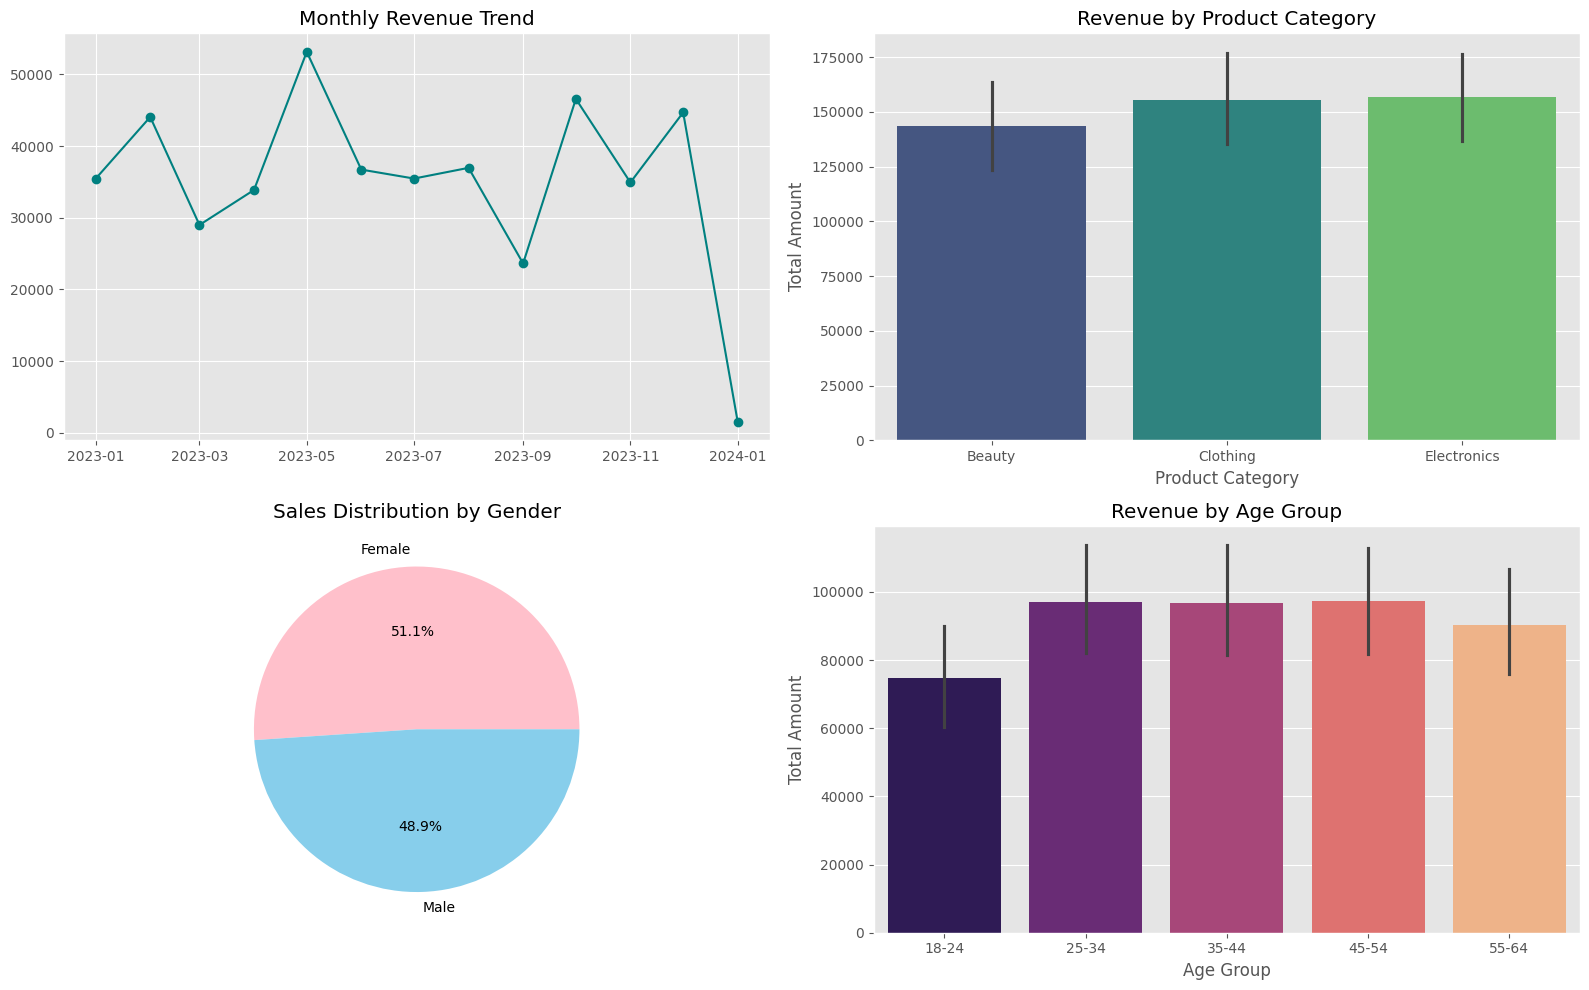

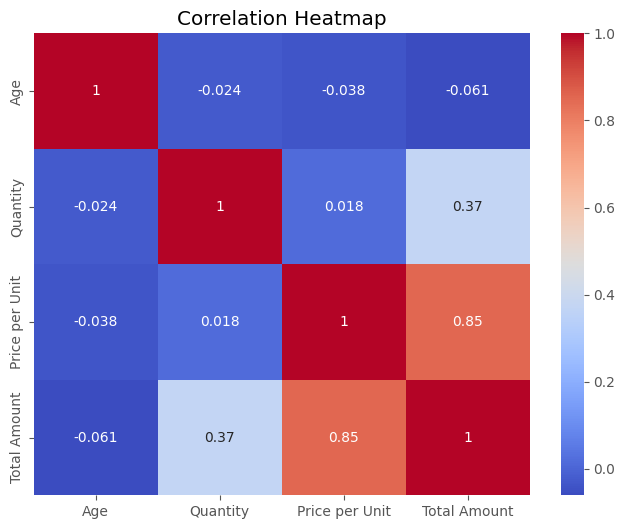

In [3]:
# Convert Date
df['Date'] = pd.to_datetime(df['Date'])

# Create Age Groups
bins = [18, 25, 35, 45, 55, 65]
labels = ['18-24', '25-34', '35-44', '45-54', '55-64']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# Extract Month for trend analysis
df['Month_Year'] = df['Date'].dt.to_period('M')

# Set the style
plt.style.use('ggplot')
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Monthly Trend
monthly = df.groupby(df['Date'].dt.to_period('M'))['Total Amount'].sum()
monthly.index = monthly.index.to_timestamp()
axes[0,0].plot(monthly.index, monthly.values, marker='o', color='teal')
axes[0,0].set_title('Monthly Revenue Trend')

# 2. Sales by Category
sns.barplot(data=df, x='Product Category', y='Total Amount', estimator=sum, ax=axes[0,1], palette='viridis')
axes[0,1].set_title('Revenue by Product Category')

# 3. Sales by Gender
gender_data = df.groupby('Gender')['Total Amount'].sum()
axes[1,0].pie(gender_data, labels=gender_data.index, autopct='%1.1f%%', colors=['pink', 'skyblue'])
axes[1,0].set_title('Sales Distribution by Gender')

# 4. Sales by Age Group
sns.barplot(data=df, x='Age Group', y='Total Amount', estimator=sum, ax=axes[1,1], palette='magma')
axes[1,1].set_title('Revenue by Age Group')

plt.tight_layout()
plt.savefig('retail_analysis_dashboard.png')

plt.figure(figsize=(8, 6))
sns.heatmap(df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('retail_correlation.png')